In [1]:
import torch
import torch.optim as optim
import torch.nn as nn
import pandas as pd
import numpy as np

from models.simple_model.model import ProtENN2_style

In [2]:
model_oh = ProtENN2_style(cnn_dim=256,
                          kernel_size=5,
                          dilation=2,
                          in_channels=21,
                          num_pfams=131)

# model_oh.load_state_dict(torch.load("./saved_models/random_oh_lr0001.pt", map_location=torch.device('cpu')))
model_oh.load_state_dict(torch.load("./models/saved_models/oh_bs_128_easy_w1-25_20e.pt", map_location=torch.device('cpu')))

<All keys matched successfully>

In [3]:
import numpy as np
import pandas as pd
import json

data = pd.read_parquet("./dataset/splits/easy/split_data.parquet",engine="fastparquet")

with open("./dataset/splits/easy/split.json") as json_file:
    data_split = json.load(json_file)



In [4]:
from models.simple_model.model_parts import CUSTOM_ALPHABET

MAX_PROTEIN_LENGTH = 1000

# One hot encode the sequences
def one_hot_encode_sequence(sequence, alphabet=CUSTOM_ALPHABET, max_length=MAX_PROTEIN_LENGTH):
    one_hot = np.zeros((max_length, len(alphabet)), dtype=np.float32)
    for i, char in enumerate(sequence):
        if i < max_length and char in alphabet:
            one_hot[i, alphabet[char]] = 1.0
    return one_hot

data["sequence_oh"] = data["sequence"].apply(one_hot_encode_sequence)

# Generate pfam to index mapping
pfam_to_index = {pfam: idx+1 for idx, pfam in enumerate(data["pfam_tensor"].explode().unique())}

# Convert pfams to indices and pad to max length
def convert_pfams_to_indices(pfams, pfam_to_index, max_length=MAX_PROTEIN_LENGTH):
    indices = [pfam_to_index[pfam] for pfam in pfams if pfam in pfam_to_index]
    if len(indices) < max_length:
        indices += [0] * (max_length - len(indices))  # Pad with zeros
    return np.array(indices[:max_length], dtype=np.int64)

data["pfams_indices"] = data["pfam_tensor"].apply(lambda x: convert_pfams_to_indices(x, pfam_to_index))

In [5]:
from torch.utils.data import TensorDataset, DataLoader

example_input = torch.tensor(np.stack(data.loc[data_split["test"]]["sequence_oh"].values), dtype=torch.float32)
labels = torch.tensor(np.stack(data.loc[data_split["test"]]["pfams_indices"].values), dtype=torch.float32)

# Create a dataset and loader
dataset = TensorDataset(example_input)
loader = DataLoader(dataset, batch_size=100)

i = 0
output = []
for (batch_inputs,) in loader:
    suboutput = model_oh(batch_inputs)
    suboutput = suboutput.argmax(dim=-1)
    output.append(suboutput)
    i+=1
    print(f'batch: {i}')

tot_output = torch.cat(output).numpy()


batch: 1
batch: 2
batch: 3
batch: 4
batch: 5
batch: 6
batch: 7
batch: 8
batch: 9
batch: 10
batch: 11
batch: 12
batch: 13
batch: 14
batch: 15
batch: 16
batch: 17
batch: 18
batch: 19
batch: 20
batch: 21
batch: 22
batch: 23
batch: 24
batch: 25
batch: 26
batch: 27
batch: 28
batch: 29
batch: 30
batch: 31
batch: 32
batch: 33
batch: 34
batch: 35
batch: 36
batch: 37
batch: 38
batch: 39
batch: 40
batch: 41
batch: 42
batch: 43
batch: 44
batch: 45
batch: 46
batch: 47
batch: 48
batch: 49
batch: 50
batch: 51
batch: 52
batch: 53
batch: 54
batch: 55
batch: 56
batch: 57


In [6]:
tot_output.shape

(5620, 1000)

In [7]:
df = pd.DataFrame({"prediction": list(tot_output), "gt": list(labels.numpy())})
df

,prediction,gt
0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 72, 1, 72, 1...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
2,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
3,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
4,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."
...,...,...
5615,"[130, 1, 130, 1, 130, 1, 130, 1, 130, 1, 130, ...","[1.0, 1.0, 130.0, 130.0, 130.0, 130.0, 130.0, ..."
5616,"[130, 1, 130, 130, 130, 130, 130, 130, 130, 13...","[1.0, 1.0, 130.0, 130.0, 130.0, 130.0, 130.0, ..."
5617,"[1, 1, 93, 1, 1, 1, 25, 1, 12, 1, 107, 1, 130,...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 130.0, 130.0, 1..."
5618,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ..."


In [8]:
from collections import defaultdict

pfam_tp_dict = defaultdict(int)
pfam_fp_dict = defaultdict(int)
pfam_fn_dict = defaultdict(int)
n=0
for index, row in df.iterrows():
    for idx in range(row["prediction"].shape[0]):
        pred = row["prediction"][idx]
        gt = row["gt"][idx]
        if pred == gt:
            pfam_tp_dict[gt] += 1
        else:
            pfam_fn_dict[gt] += 1
            pfam_fp_dict[pred] += 1
        n+=1

In [25]:
pfam_tn_dict = defaultdict(int)
for pfam in pfam_tp_dict:
    pfam_tn_dict[pfam] = n - (pfam_fp_dict[pfam] + pfam_fn_dict[pfam] + pfam_tp_dict[pfam])
pfam_tn_dict

defaultdict(int,
            {np.float32(1.0): 3493347,
             np.float32(6.0): 5614109,
             np.float32(0.0): 2376975,
             np.float32(7.0): 5613703,
             np.float32(3.0): 5615191,
             np.float32(2.0): 5619793,
             np.float32(5.0): 5617644,
             np.float32(9.0): 5619343,
             np.float32(12.0): 5615564,
             np.float32(13.0): 5612687,
             np.float32(14.0): 5612081,
             np.float32(17.0): 5616901,
             np.float32(18.0): 5617720,
             np.float32(21.0): 5618968,
             np.float32(22.0): 5617304,
             np.float32(23.0): 5613710,
             np.float32(27.0): 5618599,
             np.float32(28.0): 5617343,
             np.float32(29.0): 5616242,
             np.float32(30.0): 5602711,
             np.float32(32.0): 5600840,
             np.float32(34.0): 5608594,
             np.float32(35.0): 5585002,
             np.float32(36.0): 5610089,
             np.float32(37.0): 

In [9]:
pfams=[]
precision_list=[]
recall_list=[]
false_pos_list=[]
accuracy_list=[]
for pfam in pfam_tp_dict:
    tp = pfam_tp_dict[pfam]
    fp = pfam_fp_dict[pfam]
    fn = pfam_fn_dict[pfam]
    tn = n-(tp+fp+fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall= tp / (tp + fn)  if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision_list.append(precision)
    recall_list.append(recall)
    false_pos_list.append(fpr)
    accuracy_list.append(accuracy)
    pfams.append(pfam)

scores_df=pd.DataFrame({"pfams":pfams, "precision":precision_list, "recall":recall_list,"false positive rate":false_pos_list,"accuracy": accuracy_list})
scores_df

,pfams,precision,recall,false positive rate,accuracy
0,1.0,0.765388,0.850626,0.111824,0.876905
1,6.0,0.414354,0.643969,0.000500,0.999305
2,0.0,0.997396,0.998578,0.003535,0.997681
3,7.0,0.003486,0.011830,0.000865,0.998883
4,3.0,0.015018,0.019340,0.000479,0.999152
...,...,...,...,...,...
93,123.0,0.035062,0.038575,0.000706,0.998656
94,124.0,0.091582,0.252839,0.000590,0.999235
95,127.0,0.217984,0.076980,0.001272,0.994503
96,128.0,0.313433,0.348724,0.000336,0.999378


In [16]:
balanced_accuracy = scores_df['recall'].mean()
balanced_accuracy

np.float64(0.17676753069040865)

In [10]:
reversed_pfam_to_index = {v: k for k, v in pfam_to_index.items()}
scores_df["pfam_name"] = scores_df["pfams"].map(reversed_pfam_to_index)
counts = pd.read_pickle("./dataset/splits/easy/pfam_counts.pkl")
scores_df["counts"] = scores_df["pfam_name"].map(counts)
scores_df

,pfams,precision,recall,false positive rate,accuracy,pfam_name,counts
0,1.0,0.765388,0.850626,0.111824,0.876905,None,6806121
1,6.0,0.414354,0.643969,0.000500,0.999305,PF02817.22,24695
2,0.0,0.997396,0.998578,0.003535,0.997681,NaN,0
3,7.0,0.003486,0.011830,0.000865,0.998883,PF00198.28,13136
4,3.0,0.015018,0.019340,0.000479,0.999152,PF00578.27,9899
...,...,...,...,...,...,...,...
93,123.0,0.035062,0.038575,0.000706,0.998656,PF00264.25,20216
94,124.0,0.091582,0.252839,0.000590,0.999235,PF00984.24,42016
95,127.0,0.217984,0.076980,0.001272,0.994503,PF03635.23,77271
96,128.0,0.313433,0.348724,0.000336,0.999378,PF13920.12,12011


In [14]:
df.to_pickle("./dataset/scores/scores_oh_bs_128_easy.pkl")

/home/srear/miniconda3/envs/pp1/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


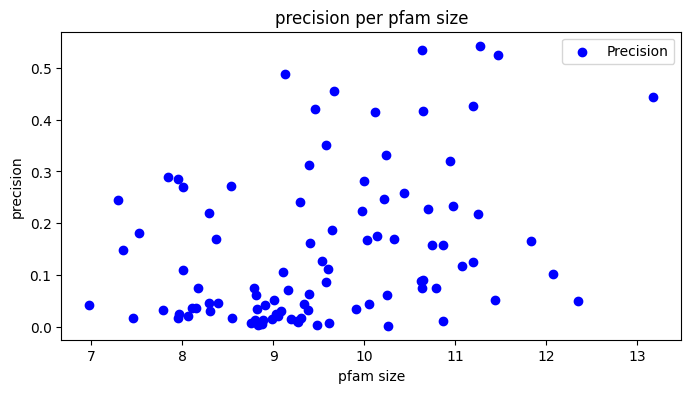

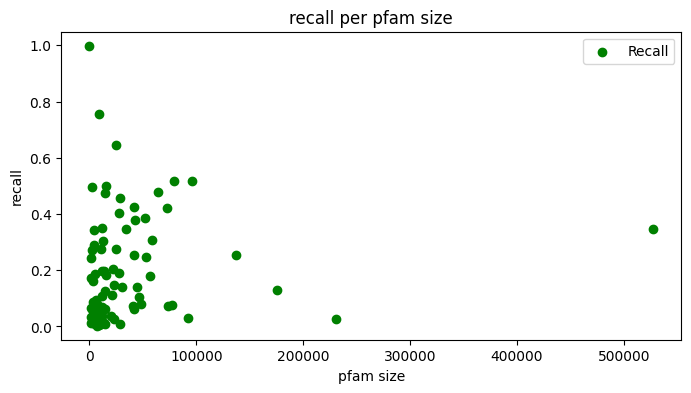

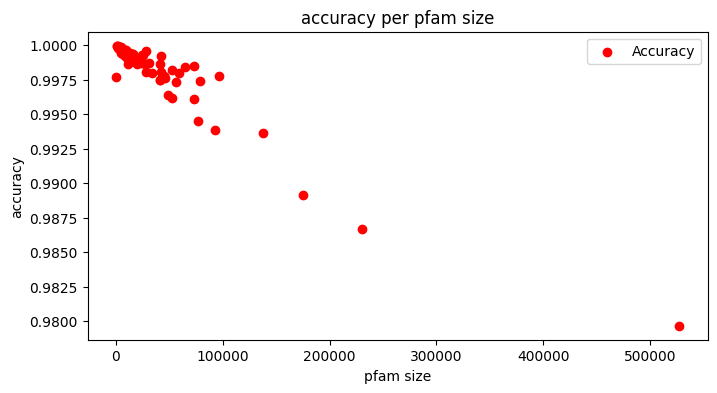

In [21]:
import matplotlib.pyplot as plt

# Scatter plot: pfams vs precision
plt.figure(figsize=(8, 4))
plt.scatter(np.log(scores_df["counts"][1:]), scores_df["precision"][1:], color='b', label='Precision')
plt.xlabel("pfam size")
plt.ylabel("precision")
plt.title("precision per pfam size")
plt.legend()
plt.show()

# Scatter plot: pfams vs recall
plt.figure(figsize=(8, 4))
plt.scatter(scores_df["counts"][1:], scores_df["recall"][1:], color='g', label='Recall')
plt.xlabel("pfam size")
plt.ylabel("recall")
plt.title("recall per pfam size")
plt.legend()
plt.show()

# Scatter plot: pfams vs accuracy
plt.figure(figsize=(8, 4))
plt.scatter(scores_df["counts"][1:], scores_df["accuracy"][1:], color='r', label='Accuracy')
plt.xlabel("pfam size")
plt.ylabel("accuracy")
plt.title("accuracy per pfam size")
plt.legend()
plt.show()

In [18]:
scores_df.sort_values(by="counts", ascending=False, inplace=True)
scores_df

,pfams,precision,recall,false positive rate,accuracy,pfam_name,counts
0,1.0,0.765388,0.850626,0.111824,0.876905,None,6806121
62,80.0,0.442966,0.346131,0.008274,0.979684,PF22725.1,527319
73,96.0,0.051359,0.027749,0.004636,0.986690,PF05649.18,230404
40,55.0,0.102999,0.128365,0.006144,0.989126,PF03600.22,175133
32,45.0,0.166118,0.253545,0.004021,0.993640,PF01312.24,137228
...,...,...,...,...,...,...,...
68,87.0,0.017857,0.013441,0.000049,0.999886,PF16680.11,1729
45,61.0,0.149351,0.065156,0.000023,0.999918,PF07939.16,1560
90,120.0,0.246006,0.244444,0.000042,0.999916,PF21789.3,1471
5,2.0,0.042105,0.034483,0.000016,0.999964,PF10417.14,1074


/tmp/ipykernel_55846/688891655.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot([scores_df[m] for m in metrics], patch_artist=True, labels=metrics)


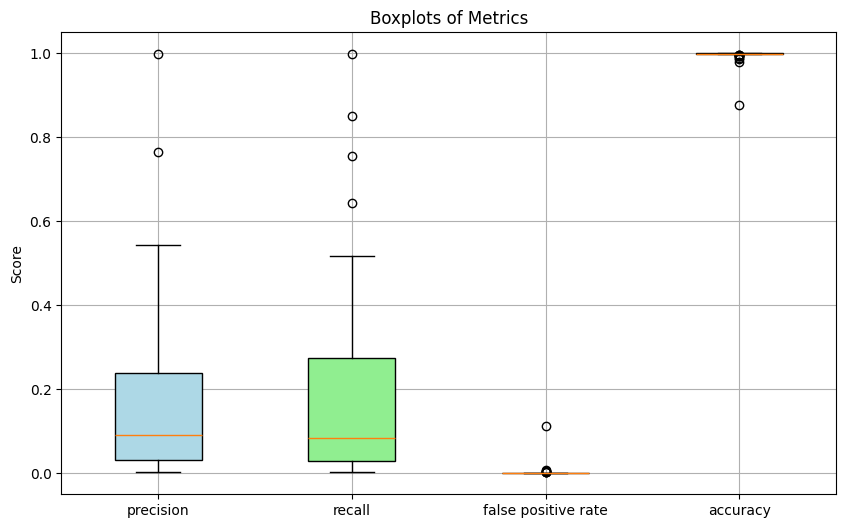

In [13]:
metrics = ["precision", "recall", "false positive rate", "accuracy"]
colors = ['lightblue', 'lightgreen', 'lightcoral', 'khaki']

plt.figure(figsize=(10, 6))
box = plt.boxplot([scores_df[m] for m in metrics], patch_artist=True, labels=metrics)

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

plt.title("Boxplots of Metrics")
plt.ylabel("Score")
plt.grid(True)
plt.show()